In [23]:
from typing import TypedDict
from langgraph.graph import START, END, StateGraph
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from dotenv import load_dotenv
load_dotenv()

True

In [24]:
llm = ChatOpenAI(model="gpt-4", temperature=0)

In [25]:
class StoryGraph(TypedDict):
    title: str
    content: str
    score: float
    improvement: str

In [26]:
def content_creator(state: StoryState) -> StoryState:
    # Create the content for the test
    title = state["title"]
    prompt_template = ChatPromptTemplate.from_template("Write a 100-word story about {title}.")
    chain = prompt_template | llm
    response = chain.invoke({"title": title})
    return {"content": response.content}

def quiz_creator(state: StoryState) -> StoryState:
    # Create a quiz based on the content
    content = state["content"]
    prompt_template = ChatPromptTemplate.from_template("Create a 5-question multiple choicequiz based on the following content: {content}")
    chain = prompt_template | llm
    response = chain.invoke({"content": content})
    return {"quiz": response.content}

def rate_story(state: StoryState) -> StoryState:
    # Rate the story
    content = state["content"]
    prompt_template = ChatPromptTemplate.from_template("Rate the following story on a scale of 1-10 with 1 being lowest and 10 being highest: {content}")
    chain = prompt_template | llm
    response = chain.invoke({"content": content})
    return {"score": float(response.content)}

def suggest_improvement(state: StoryState) -> StoryState:
    # Create a suggestion for improvement
    content = state["content"]
    prompt_template = ChatPromptTemplate.from_template("Provide a suggestion for improving the following story: {content}")
    chain = prompt_template | llm
    response = chain.invoke({"content": content})
    return {"improvement": response.content}

In [27]:
# Create a parallel workflow for the test

graph = StateGraph(StoryGraph)

# Add nodes to graph
graph.add_node("content", content_creator)
graph.add_node("quiz", quiz_creator)
graph.add_node("rate", rate_story)
graph.add_node("improve", suggest_improvement)


# Add edges to graph
graph.add_edge(START, "content")
graph.add_edge("content", "quiz")
graph.add_edge("content", "rate")
graph.add_edge("content", "improve")
graph.add_edge("quiz", END)
graph.add_edge("rate", END)
graph.add_edge("improve", END)

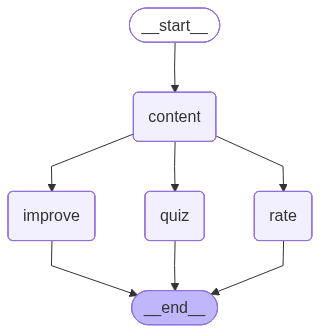

In [28]:
app = graph.compile()
app

In [29]:
initial_state = {
    "title": "Life of an Orange",
}
result = app.invoke(initial_state)
print("Title: " + result['title'])
print("\nContent: ")
print(result['content'])
print("\nScore: ")
print(result['score'])
print("\nImprovement: ")
print(result['improvement'])

Title: Life of an Orange

Content: 
Born as a tiny blossom on a leafy tree, I grew under the warm sun and cool rain. I transformed from a delicate flower to a small green fruit, gradually maturing into a vibrant orange sphere. Picked at the peak of my ripeness, I journeyed to a bustling market. A little girl chose me, her eyes sparkling with delight. At home, she peeled off my skin, revealing my juicy segments. As she savored each piece, I fulfilled my purpose, providing her with sweet delight and nourishing vitamins. Thus, in my simple existence, I experienced growth, change, and the joy of giving.

Score: 
8.5

Improvement: 
Born as a tiny blossom on a verdant tree, I flourished under the nurturing warmth of the sun and the refreshing touch of the rain. My transformation from a delicate flower to a small green fruit was a gradual process, eventually maturing into a vibrant orange sphere, a testament to the passage of time. Harvested at the peak of my ripeness, I embarked on a journey